In [109]:
import json
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [67]:
def normalize_label(label_text):
    if label_text.lower().startswith('support'):
        return 'Supports'
    elif label_text.lower().startswith('oppose'):
        return 'Opposes'
    elif label_text.lower() == 'either':
        return 'Either'
    return 'N/A'

In [68]:
def extract_label_from_raw_output(raw_output):
    if not isinstance(raw_output, str):
        return "N/A", "None"

    label_variations_pattern = r"(Support(?:s|es)?|Oppose(?:s)?|Either)"

    # Rule 1: Find "Fast thinking Label: <LABEL>" or "Slow thinking label: <LABEL>" (most specific)
    match_rule1 = re.search(r'(?:Fast thinking Label:|Slow thinking label:)\s*(' + label_variations_pattern + ')', raw_output, re.IGNORECASE)
    if match_rule1:
        return normalize_label(match_rule1.group(1)), "Rule 1"

    # Rule 2: Find "Fast thinking label" or "Slow thinking label" then search for any of the 3 words after it.
    # This handles cases like "Slow thinking label is: support" or "Slow thinking label would be: Oppose"
    match_rule2 = re.search(r'(?:Fast thinking label|Slow thinking label)[\s\S]*?(' + label_variations_pattern + ')', raw_output, re.IGNORECASE)
    if match_rule2:
        return normalize_label(match_rule2.group(1)), "Rule 2"

    # Rule 3: Find the "Solution" section, then search for any of the three words
    match_rule3 = re.search(r'Solution[\s\S]*?(' + label_variations_pattern + ')', raw_output, re.IGNORECASE | re.DOTALL)
    if match_rule3:
        return normalize_label(match_rule3.group(1)), "Rule 3"

    # Rule 4: Find any of the three words directly in the text (last resort)
    match_rule4 = re.search(label_variations_pattern, raw_output, re.IGNORECASE)
    if match_rule4:
        return normalize_label(match_rule4.group(1)), "Rule 4"

    return "N/A", "None" # If no label is found after all rules

In [69]:
def analyze_rule_distribution(data_frame, rule_col, thinking_mode, results):
    print(f"{thinking_mode} Rule Distribution:")
    if rule_col in data_frame.columns:
        rule_dist = data_frame[rule_col].value_counts()
        display(rule_dist)
        results[f"{thinking_mode.replace(' ', '')} Rule Distribution"] = rule_dist.to_dict()
    else:
        print(f"{thinking_mode} rule column '{rule_col}' not found.")
        results[f"{thinking_mode.replace(' ', '')} Rule Distribution"] = {}


### Modular Analysis Function

This function will encapsulate all the analysis steps (accuracy, overthinking, correction, and distributions) to make it reusable for multiple datasets.

In [ ]:
def perform_analysis(data_frame, dataset_name="Dataset", type="not"):
    results = {"Dataset": dataset_name}

    print(f"\n--- Analysis for {dataset_name} ---")

    # Determine which label columns to use based on the 'type' argument
    if type == "anchor":
        fast_rule_col = 'llm_fast_thinking_rule_anchored'
        slow_rule_col = 'llm_slow_thinking_rule_anchored'
    else:
        fast_rule_col = 'llm_fast_thinking_rule'
        slow_rule_col = 'llm_slow_thinking_rule'

    # Parsing Rule Distribution
    print("\n--- Parsing Rule Distribution ---")
    analyze_rule_distribution(data_frame, fast_rule_col, "Fast Thinking", results)
    analyze_rule_distribution(data_frame, slow_rule_col, "Slow Thinking", results)

    total_data_points = len(data_frame)

    # Calculate correct counts
    fast_correct_count = data_frame['fast_correct'].sum()
    slow_correct_count = data_frame['slow_correct'].sum()

    # New Accuracy definitions as rates
    fast_accuracy = fast_correct_count / total_data_points if total_data_points > 0 else 0
    slow_accuracy = slow_correct_count / total_data_points if total_data_points > 0 else 0

    results["Fast Correct Count"] = fast_correct_count
    results["Slow Correct Count"] = slow_correct_count
    results["Fast Accuracy"] = f"{fast_accuracy:.2%}"
    results["Slow Accuracy"] = f"{slow_accuracy:.2%}"

    print(f"\nFast Thinking Accuracy (CKR): {fast_accuracy:.2%}")
    print(f"Slow Thinking Accuracy (CKR + CRA): {slow_accuracy:.2%}")

    # New Capability Metrics
    # CKR (Capability Knowledge Retrieval) is Fast Accuracy
    capability_knowledge_retrieval = fast_accuracy

    # CRA (Capability Reasoning Adjustment) or Reasoning Gain
    capability_reasoning_adjustment = slow_accuracy - fast_accuracy

    results["Capability Knowledge Retrieval (CKR)"] = f"{capability_knowledge_retrieval:.2%}"
    results["Capability Reasoning Adjustment (CRA)"] = f"{capability_reasoning_adjustment:.2%}"

    print(f"Capability Knowledge Retrieval (CKR = Fast Accuracy): {capability_knowledge_retrieval:.2%}")
    print(f"Capability Reasoning Adjustment (CRA = Slow Accuracy - Fast Accuracy): {capability_reasoning_adjustment:.2%}")

    # 2. Overthinking Analysis
    # Count of data points where fast_correct=1 and slow_correct=0
    overthinking_count = data_frame[(data_frame['fast_correct'] == 1) & (data_frame['slow_correct'] == 0)].shape[0]
    results["Overthinking Count"] = overthinking_count
    print(f"\nNumber of rows with Overthinking (fast_correct=1, slow_correct=0): {overthinking_count}")

    # Calculate Overthinking Rate
    fast_correct_total_for_rate = data_frame[data_frame['fast_correct'] == 1].shape[0]
    if fast_correct_total_for_rate > 0:
        overthinking_rate = overthinking_count / fast_correct_total_for_rate
        results["Overthinking Rate"] = f"{overthinking_rate:.2%}"
        print(f"Overthinking Rate (overthinking / fast_correct_total): {overthinking_rate:.2%}")
    else:
        results["Overthinking Rate"] = "N/A (No fast correct predictions)"
        print("Overthinking Rate: N/A (No fast correct predictions)")

    # 3. Correction Analysis
    # Count of data points where fast_correct=0 and slow_correct=1
    correction_count = data_frame[(data_frame['fast_correct'] == 0) & (data_frame['slow_correct'] == 1)].shape[0]
    results["Correction Count"] = correction_count
    print(f"\nNumber of rows with Correction (fast_correct=0, slow_correct=1): {correction_count}")

    # Calculate Correction Rate
    fast_incorrect_total_for_rate = data_frame[data_frame['fast_correct'] == 0].shape[0]
    if fast_incorrect_total_for_rate > 0:
        correction_rate = correction_count / fast_incorrect_total_for_rate
        results["Correction Rate"] = f"{correction_rate:.2%}"
        print(f"Correction Rate (correction / fast_incorrect_total): {correction_rate:.2%}")
    else:
        results["Correction Rate"] = "N/A (No fast incorrect predictions)"
        print("Correction Rate: N/A (No fast incorrect predictions)")

    print(f"--- End of Analysis for {dataset_name} ---")

    return results

### Valence Label Distribution Analysis (Top 1000 from valence_test.csv)

In [71]:
# Load valence_test.csv
valence_df = pd.read_csv('/content/valence_test.csv')

# Get the top 1000 rows
valence_df_top1000 = valence_df.head(1000)

print("\n--- Valence Label Distribution (Top 1000 rows) ---")
valence_distribution = valence_df_top1000['valence'].value_counts()
display(valence_distribution)



--- Valence Label Distribution (Top 1000 rows) ---


,count
valence,
Supports,489
Opposes,377
Either,134


### Details for 'either' valence labels (Top 1000 rows)

In [87]:
# Filter for 'either' cases
either_cases = valence_df_top1000[valence_df_top1000['valence'] == 'Either']


### Applying the Modular Analysis

Now, let's apply the `perform_analysis` function to our current DataFrame (`df`) and demonstrate how you would use it for additional datasets.

In [73]:
print("================================== INDEPENDENT APPROACH ANALYSIS ==================================")
analysis_results = []

# Dataset 1
with open("/content/qwen2.5_1.5B_results.json", "r", encoding="utf-8") as f:
    data2 = json.load(f)
df2 = pd.DataFrame(data2)
df2['llm_fast_thinking_label'], df2['llm_fast_thinking_rule'] = zip(*df2['llm_raw_output_fast'].apply(extract_label_from_raw_output))
df2['llm_slow_thinking_label'], df2['llm_slow_thinking_rule'] = zip(*df2['llm_raw_output_slow'].apply(extract_label_from_raw_output))
df2["fast_correct"] = (df2["llm_fast_thinking_label"] == df2["valence"]).astype(int)
df2["slow_correct"] = (df2["llm_slow_thinking_label"] == df2["valence"]).astype(int)
analysis_results.append(perform_analysis(df2, dataset_name="Qwen1.5B"))

# Dataset 2
with open("/content/qwen2.5_3B_results.json", "r", encoding="utf-8") as f:
    data = json.load(f)
df = pd.DataFrame(data)
df['llm_fast_thinking_label'], df['llm_fast_thinking_rule'] = zip(*df['llm_raw_output_fast'].apply(extract_label_from_raw_output))
df['llm_slow_thinking_label'], df['llm_slow_thinking_rule'] = zip(*df['llm_raw_output_slow'].apply(extract_label_from_raw_output))
df["fast_correct"] = (df["llm_fast_thinking_label"] == df["valence"]).astype(int)
df["slow_correct"] = (df["llm_slow_thinking_label"] == df["valence"]).astype(int)
analysis_results.append(perform_analysis(df, dataset_name="Qwen3B"))

# Dataset 3
with open("/content/qwen2.5_7B_results.json", "r", encoding="utf-8") as f:
    data3 = json.load(f)
df3 = pd.DataFrame(data3)
df3['llm_fast_thinking_label'], df3['llm_fast_thinking_rule'] = zip(*df3['llm_raw_output_fast'].apply(extract_label_from_raw_output))
df3['llm_slow_thinking_label'], df3['llm_slow_thinking_rule'] = zip(*df3['llm_raw_output_slow'].apply(extract_label_from_raw_output))
df3["fast_correct"] = (df3["llm_fast_thinking_label"] == df3["valence"]).astype(int)
df3["slow_correct"] = (df3["llm_slow_thinking_label"] == df3["valence"]).astype(int)
analysis_results.append(perform_analysis(df3, dataset_name="Qwen7B"))

print("================================== ANCHORING ANALYSIS ==================================")
# Dataset 4
with open("/content/qwen2.5_7B_anchored_results.json", "r", encoding="utf-8") as f:
    data4 = json.load(f)
df4 = pd.DataFrame(data4)
df4['llm_fast_thinking_label_anchored'], df4['llm_fast_thinking_rule_anchored'] = zip(*df4['llm_raw_output_fast_anchored'].apply(extract_label_from_raw_output))
df4['llm_slow_thinking_label_anchored'], df4['llm_slow_thinking_rule_anchored'] = zip(*df4['llm_raw_output_slow_anchored'].apply(extract_label_from_raw_output))
df4["fast_correct"] = (df4["llm_fast_thinking_label_anchored"] == df4["valence"]).astype(int)
df4["slow_correct"] = (df4["llm_slow_thinking_label_anchored"] == df4["valence"]).astype(int)
analysis_results.append(perform_analysis(df4, dataset_name="Qwen7B Anchor", type="anchor"))


print("\n================================== AGGREGATED ANALYSIS RESULTS ==================================")
results_df = pd.DataFrame(analysis_results)
display(results_df)


================================== INDEPENDENT APPROACH ANALYSIS ==================================

--- Analysis for Qwen1.5B ---

--- Parsing Rule Distribution ---
Fast Thinking Rule Distribution:


,count
llm_fast_thinking_rule,
Rule 1,924
Rule 4,73
Rule 2,3


Slow Thinking Rule Distribution:


,count
llm_slow_thinking_rule,
Rule 1,968
Rule 2,32



Fast Thinking Accuracy (CKR): 50.10%
Slow Thinking Accuracy (CKR + CRA): 47.40%
Capability Knowledge Retrieval (CKR = Fast Accuracy): 50.10%
Capability Reasoning Adjustment (CRA = Slow Accuracy - Fast Accuracy): -2.70%

Number of rows with Overthinking (fast_correct=1, slow_correct=0): 111
Overthinking Rate (overthinking / fast_correct_total): 22.16%

Number of rows with Correction (fast_correct=0, slow_correct=1): 84
Correction Rate (correction / fast_incorrect_total): 16.83%
--- End of Analysis for Qwen1.5B ---

--- Analysis for Qwen3B ---

--- Parsing Rule Distribution ---
Fast Thinking Rule Distribution:


...

,count
llm_fast_thinking_rule_anchored,
Rule 1,1000


Slow Thinking Rule Distribution:


,count
llm_slow_thinking_rule_anchored,
Rule 1,956
Rule 2,42
Rule 3,2



Fast Thinking Accuracy (CKR): 23.80%
Slow Thinking Accuracy (CKR + CRA): 18.50%
Capability Knowledge Retrieval (CKR = Fast Accuracy): 23.80%
Capability Reasoning Adjustment (CRA = Slow Accuracy - Fast Accuracy): -5.30%

Number of rows with Overthinking (fast_correct=1, slow_correct=0): 162
Overthinking Rate (overthinking / fast_correct_total): 68.07%

Number of rows with Correction (fast_correct=0, slow_correct=1): 109
Correction Rate (correction / fast_incorrect_total): 14.30%
--- End of Analysis for Qwen7B Anchor ---

================================== AGGREGATED ANALYSIS RESULTS ==================================


,Dataset,FastThinking Rule Distribution,SlowThinking Rule Distribution,Fast Correct Count,Slow Correct Count,Fast Accuracy,Slow Accuracy,Capability Knowledge Retrieval (CKR),Capability Reasoning Adjustment (CRA),Overthinking Count,Overthinking Rate,Correction Count,Correction Rate
0,Qwen1.5B,"{'Rule 1': 924, 'Rule 4': 73, 'Rule 2': 3}","{'Rule 1': 968, 'Rule 2': 32}",501,474,50.10%,47.40%,50.10%,-2.70%,111,22.16%,84,16.83%
1,Qwen3B,"{'Rule 1': 993, 'Rule 4': 7}","{'Rule 1': 992, 'Rule 2': 8}",573,208,57.30%,20.80%,57.30%,-36.50%,507,88.48%,142,33.26%
2,Qwen7B,"{'Rule 1': 993, 'Rule 4': 7}","{'Rule 1': 829, 'Rule 2': 166, 'Rule 3': 5}",646,271,64.60%,27.10%,64.60%,-37.50%,480,74.30%,105,29.66%
3,Qwen7B Anchor,{'Rule 1': 1000},"{'Rule 1': 956, 'Rule 2': 42, 'Rule 3': 2}",238,185,23.80%,18.50%,23.80%,-5.30%,162,68.07%,109,14.30%


### Calculating and Adding 'Slow Label Distribution (Overthinking)'

In [74]:
# Helper to get the correct slow_label_col based on type
def get_slow_label_col_for_analysis(df_type):
    if df_type == "anchor":
        return 'llm_slow_thinking_label_anchored'
    else:
        return 'llm_slow_thinking_label'

# Create a list of tuples (dataframe, dataset_name, type) for detailed analysis
datasets_info_for_detailed_analysis = [
    (df2, "Qwen1.5B", "not"),
    (df, "Qwen3B", "not"),
    (df3, "Qwen7B", "not"),
    (df4, "Qwen7B Anchor", "anchor")
]

# Initialize a list to store the new distribution data
all_slow_label_distributions = []

for current_df, dataset_name, df_type in datasets_info_for_detailed_analysis:
    slow_label_col = get_slow_label_col_for_analysis(df_type)

    # Re-calculate overthinking cases and their slow label distribution
    overthinking_cases_df = current_df[(current_df['fast_correct'] == 1) & (current_df['slow_correct'] == 0)]

    if not overthinking_cases_df.empty and slow_label_col in overthinking_cases_df.columns:
        slow_label_distribution = overthinking_cases_df[slow_label_col].value_counts().to_dict()
    else:
        slow_label_distribution = {}

    all_slow_label_distributions.append({
        "Dataset": dataset_name,
        "Slow Label Distribution (Overthinking)": slow_label_distribution
    })

# Convert to DataFrame
slow_label_dist_df = pd.DataFrame(all_slow_label_distributions)

# Merge this new data back into results_df
# Ensure that if 'Slow Label Distribution (Overthinking)' already exists, it is overwritten or handled correctly
if 'Slow Label Distribution (Overthinking)' in results_df.columns:
    results_df = results_df.drop(columns=['Slow Label Distribution (Overthinking)'])

results_df = pd.merge(results_df, slow_label_dist_df, on='Dataset', how='left')

# Verify the column is added and display
print("Updated results_df with 'Slow Label Distribution (Overthinking)':")
display(results_df[['Dataset', 'Slow Label Distribution (Overthinking)']])

Updated results_df with 'Slow Label Distribution (Overthinking)':


,Dataset,Slow Label Distribution (Overthinking)
0,Qwen1.5B,"{'Supports': 80, 'Either': 25, 'Opposes': 6}"
1,Qwen3B,"{'Either': 494, 'Supports': 7, 'Opposes': 6}"
2,Qwen7B,"{'Either': 467, 'Opposes': 7, 'Supports': 6}"
3,Qwen7B Anchor,"{'Either': 151, 'Supports': 11}"


### Restored: Slow Label Distribution for Overthinking Cases Plot

The plot for 'Slow Label Distribution for Overthinking Cases' has been restored, now that the necessary data is available in `results_df`.

In [75]:
results_df.to_json('analysis_results.json', orient='records', indent=4)

# SETUP

In [76]:
all_dfs = {
    "Qwen1.5B": df2,
    "Qwen3B": df,
    "Qwen7B": df3,
    "Qwen7B Anchor": df4
}

# Define a consistent color map for the labels
color_map = {
    'Supports': '#66c2a5', # A shade of green
    'Opposes': '#fc8d62',  # A shade of orange/red
    'Either': '#8da0cb',   # A shade of blue/purple
}

### Valence Label Distribution in `valence_df_top1000`

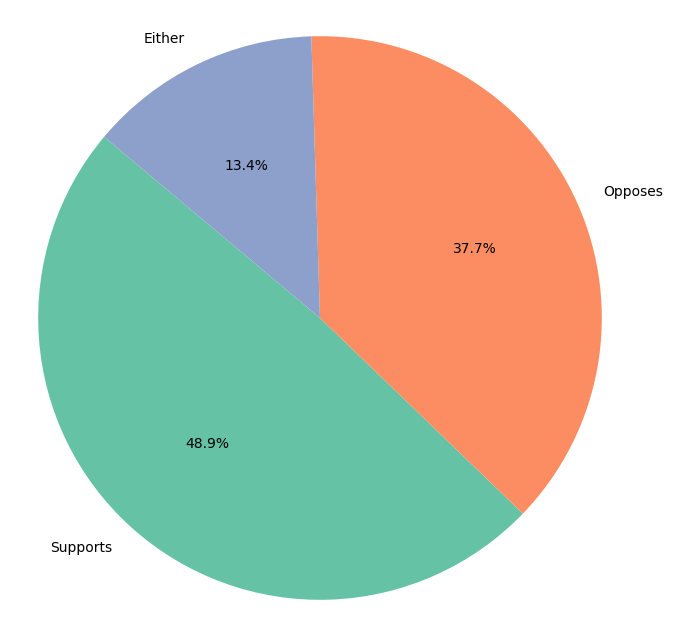

In [77]:
plt.figure(figsize=(8, 8))
valence_counts = valence_df_top1000['valence'].value_counts()

# Get labels and map them to consistent colors
labels = valence_counts.index.tolist()
sizes = valence_counts.values.tolist()
colors = [color_map.get(label, '#cccccc') for label in labels] # Use the defined color_map

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)
plt.ylabel('') # Hide the default 'valence' ylabel
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# FINDINGS: Reasoning model ga always buat dia jawab either

# Filter for cases where valence is 'Either' and slow thinking label is 'Supports' in df3

> memang kemampuan model nya. no insights gain.

In [ ]:
# Filter for cases where valence is 'Either' and slow thinking label is 'Opposes' in df3
filtered_df2_for_display = df2[
    (df2['valence'] == 'Either') &
    (df2['llm_slow_thinking_label'] == 'Supports')
]

if not filtered_df2_for_display.empty:
    print(f"\n--- Fast Thinking Extraction Verification (valence='Either', slow_label='Opposes') in Qwen2.5_7B ---\n")
    for index, row in filtered_df2_for_display.head(10).iterrows(): # Displaying first 10 such cases
        print(f"ID: {row['id']}")
        print(f"  Ground Truth Valence: {row['valence']}")
        print(f"  Fast Raw Output: {row['llm_raw_output_fast']}")
        print(f"  Fast Parsed Label: {row['llm_fast_thinking_label']}")
        print(f"  Fast Rule Used: {row['llm_fast_thinking_rule']}")
        print("---------------------------------")

    print(f"\n--- Slow Thinking Extraction Verification (valence='Either', slow_label='Opposes') in Qwen2.5_7B ---\n")
    for index, row in filtered_df2_for_display.head(10).iterrows(): # Displaying first 10 such cases
        print(f"ID: {row['id']}")
        print(f"  Ground Truth Valence: {row['valence']}")
        print(f"  Slow Raw Output: {row['llm_raw_output_slow']}")
        print(f"  Slow Parsed Label: {row['llm_slow_thinking_label']}")
        print(f"  Slow Rule Used: {row['llm_slow_thinking_rule']}")
        print("---------------------------------")
else:
    print("No cases found in Qwen2.5_7B where valence is 'Either' and slow thinking label is 'Opposes'.")


### Comparative Analysis: 3B 'Either' Valence (Slow Label 'Either') vs. 7B Divergence

Let's specifically look at instances where the Qwen-3B model had a `valence` of 'Either' and its `llm_slow_thinking_label` was also 'Either'. Then, we'll examine how the Qwen2.5_7B model's `llm_slow_thinking_label` behaves for these exact cases, focusing on where it diverges from 'Either'.


> memang modelnya give wrong answer aja. no insights from this one.

In [ ]:
# 1. Identify cases in df (Qwen-3B) where valence is 'Either' AND slow thinking label is 'Either'
either_valence_either_slow_3b_df = df[
    (df['valence'] == 'Either') &
    (df['llm_slow_thinking_label'] == 'Either')
].copy()

print(f"Total cases in Qwen-3B with valence 'Either' and slow label 'Either': {len(either_valence_either_slow_3b_df)}")

if not either_valence_either_slow_3b_df.empty:
    print("\n--- Comparing Qwen-3B (Valence 'Either', Slow Label 'Either') with Qwen2.5_7B ---")

    # 2. Merge with df3 (Qwen2.5_7B) to get corresponding rows for comparison
    merged_compare_either_df = pd.merge(
        either_valence_either_slow_3b_df[['id', 'valence', 'llm_raw_output_slow', 'llm_slow_thinking_label']],
        df3[['id', 'llm_raw_output_slow', 'llm_slow_thinking_label']],
        on='id',
        suffixes=('_3B', '_7B')
    )

    # 3. Filter for cases where the 7B model's slow thinking label is NOT 'Either'
    divergent_7b_label_df = merged_compare_either_df[merged_compare_either_df['llm_slow_thinking_label_7B'] != 'Either']

    if not divergent_7b_label_df.empty:
        print(f"\nCases where Qwen-3B had (Valence 'Either', Slow Label 'Either') and Qwen2.5_7B's slow label is NOT 'Either': {len(divergent_7b_label_df)}")
        for index, row in divergent_7b_label_df.head(10).iterrows(): # Displaying first 10 cases
            print(f"\nID: {row['id']}")
            print(f"  Ground Truth Valence: {row['valence']}")
            print(f"  Qwen-3B Slow Raw Output: {row['llm_raw_output_slow_3B']}")
            print(f"  Qwen-3B Slow Parsed Label: {row['llm_slow_thinking_label_3B']}")
            print(f"  Qwen2.5_7B Slow Raw Output: {row['llm_raw_output_slow_7B']}")
            print(f"  Qwen2.5_7B Slow Parsed Label: {row['llm_slow_thinking_label_7B']}")
            print("---------------------------------")
    else:
        print("\nNo cases found where Qwen-3B had (Valence 'Either', Slow Label 'Either') and Qwen2.5_7B's slow label is NOT 'Either'.")

    # Optionally, display cases where 7B is also 'Either' (for completeness)
    same_7b_label_either_df = merged_compare_either_df[merged_compare_either_df['llm_slow_thinking_label_7B'] == 'Either']
    if not same_7b_label_either_df.empty:
        print(f"\nCases where Qwen-3B had (Valence 'Either', Slow Label 'Either') and Qwen2.5_7B's slow label is ALSO 'Either': {len(same_7b_label_either_df)}")
        # You can add display for these cases if needed
else:
    print("No cases found in Qwen-3B with valence 'Either' and a slow thinking label of 'Either'.")

# FINDINGS: Reasoning model ga always buat dia ga kena anchor. Anchor keliatan kek ga masuk konsideration di reasoning section

# Filter for correct slow thinking predictions in anchored data (df4)

> thinks and reasons as usual. no muter" karena anchor

In [ ]:
# Filter for correct slow thinking predictions in anchored data (df4)
correct_slow_anchored_df = df4[df4['slow_correct'] == 1]

if not correct_slow_anchored_df.empty:
    print(f"\n--- Correct Slow Thinking Anchored Predictions (Qwen2.5_7B) ---\n")
    print(f"Total correct slow thinking anchored predictions: {len(correct_slow_anchored_df)}")
    for index, row in correct_slow_anchored_df.head(5).iterrows():
        print(f"ID: {row['id']}")
        print(f"  Ground Truth Valence: {row['valence']}")
        print(f"  Slow Anchored Raw Output: {row['llm_raw_output_slow_anchored']}")
        print(f"  Slow Anchored Parsed Label: {row['llm_slow_thinking_label_anchored']}")
        print(f"  Slow Anchored Rule Used: {row['llm_slow_thinking_rule_anchored']}")
        print("---------------------------------")
else:
    print("No correct slow thinking anchored predictions found.")

# Filter for incorrect slow thinking predictions in anchored data (df4)
incorrect_slow_anchored_df = df4[df4['slow_correct'] == 0]

if not incorrect_slow_anchored_df.empty:
    print(f"\n--- Incorrect Slow Thinking Anchored Predictions (Qwen2.5_7B) ---\n")
    print(f"Total incorrect slow thinking anchored predictions: {len(incorrect_slow_anchored_df)}")
    for index, row in incorrect_slow_anchored_df.head(5).iterrows():
        print(f"ID: {row['id']}")
        print(f"  Ground Truth Valence: {row['valence']}")
        print(f"  Slow Anchored Raw Output: {row['llm_raw_output_slow_anchored']}")
        print(f"  Slow Anchored Parsed Label: {row['llm_slow_thinking_label_anchored']}")
        print(f"  Slow Anchored Rule Used: {row['llm_slow_thinking_rule_anchored']}")
        print("---------------------------------")
else:
    print("No incorrect slow thinking anchored predictions found.")

### Filter for Incorrect Slow Thinking Predictions in Anchored Data



> kesimpulan: perhaps bakal ada reasoning yang ga kebawa anchor di model yang lebih tinggi size param. karena dari output sekarang ga show kalo dia ada effort untuk refute anchor.

> model thinks as usual, but somehow some label changes



In [ ]:
# Filter for incorrect slow thinking predictions in anchored data (df4), excluding 'Either' labels
incorrect_slow_anchored_df = df4[
    (df4['slow_correct'] == 0) &
    (df4['llm_slow_thinking_label_anchored'] != 'Either')
]

if not incorrect_slow_anchored_df.empty:
    print(f"\n--- Incorrect Slow Thinking Anchored Predictions (Qwen2.5_7B, excluding 'Either' labels) ---\n")
    print(f"Total incorrect slow thinking anchored predictions: {len(incorrect_slow_anchored_df)}")
    for index, row in incorrect_slow_anchored_df.head(5).iterrows():
        print(f"ID: {row['id']}")
        print(f"  Ground Truth Valence: {row['valence']}")
        print(f"  Slow Anchored Raw Output: {row['llm_raw_output_slow_anchored']}")
        print(f"  Slow Anchored Parsed Label: {row['llm_slow_thinking_label_anchored']}")
        print(f"  Slow Anchored Rule Used: {row['llm_slow_thinking_rule_anchored']}")
        print("---------------------------------")
else:
    print("No incorrect slow thinking anchored predictions found (excluding 'Either' labels).")

### Overthinking Rate and Correction Rate Across Models (Line Chart)

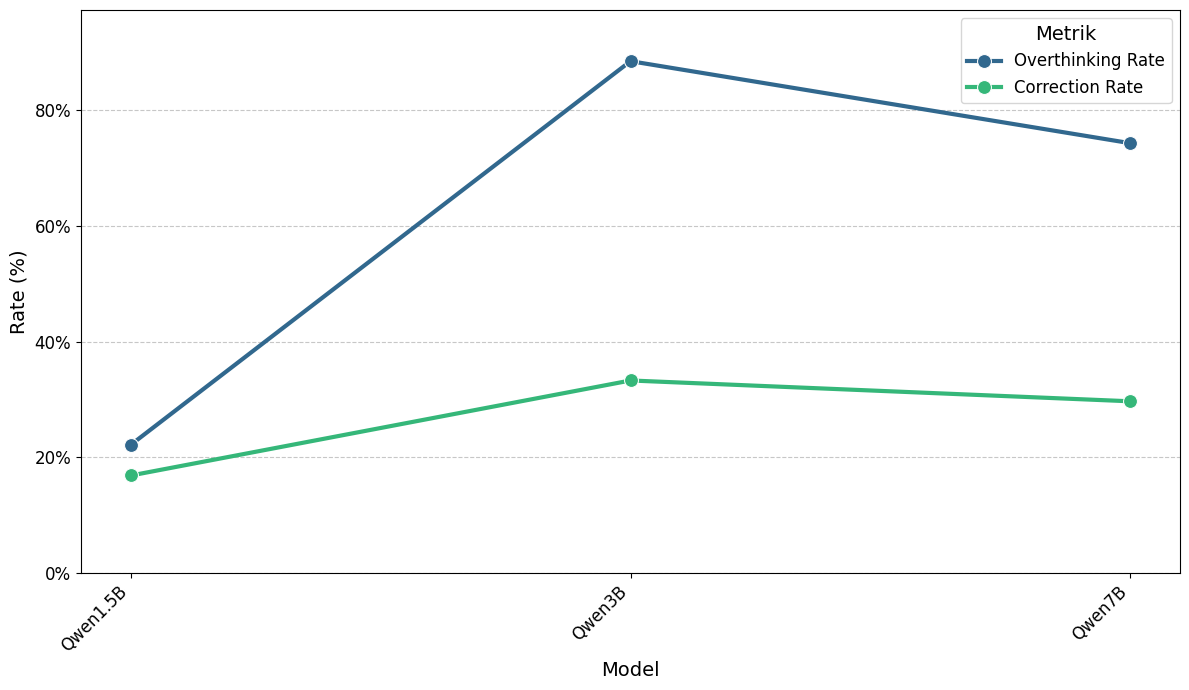

In [107]:
chart1_df = results_df[results_df['Dataset'] != 'Qwen7B Anchor'].copy()

# Convert percentage strings to float
chart1_df['Overthinking Rate'] = chart1_df['Overthinking Rate'].str.rstrip('%').astype(float) / 100
chart1_df['Correction Rate'] = chart1_df['Correction Rate'].str.rstrip('%').astype(float) / 100

# Melt the DataFrame for plotting
chart1_melted = chart1_df.melt(
    id_vars='Dataset',
    value_vars=['Overthinking Rate', 'Correction Rate'],
    var_name='Metric',
    value_name='Rate'
)

plt.figure(figsize=(12, 7))
ax = sns.lineplot(x='Dataset', y='Rate', hue='Metric', data=chart1_melted, marker='o', palette='viridis', linewidth=3, markersize=10)
plt.xlabel('Model', fontsize=14)
plt.ylabel('Rate (%)', fontsize=14)
plt.ylim(0, chart1_melted['Rate'].max() * 1.1) # Adjust y-limit dynamically
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y))) # Format as percentage
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right', fontsize=12)

plt.yticks(fontsize=12)
plt.legend(title='Metrik', fontsize=12, title_fontsize=14)
plt.tight_layout()
plt.show()

### Chart 2: Fast vs. Slow Accuracy and Reasoning Gain (CRA) for Qwen7B vs. Qwen7B Anchor (Bar Chart)

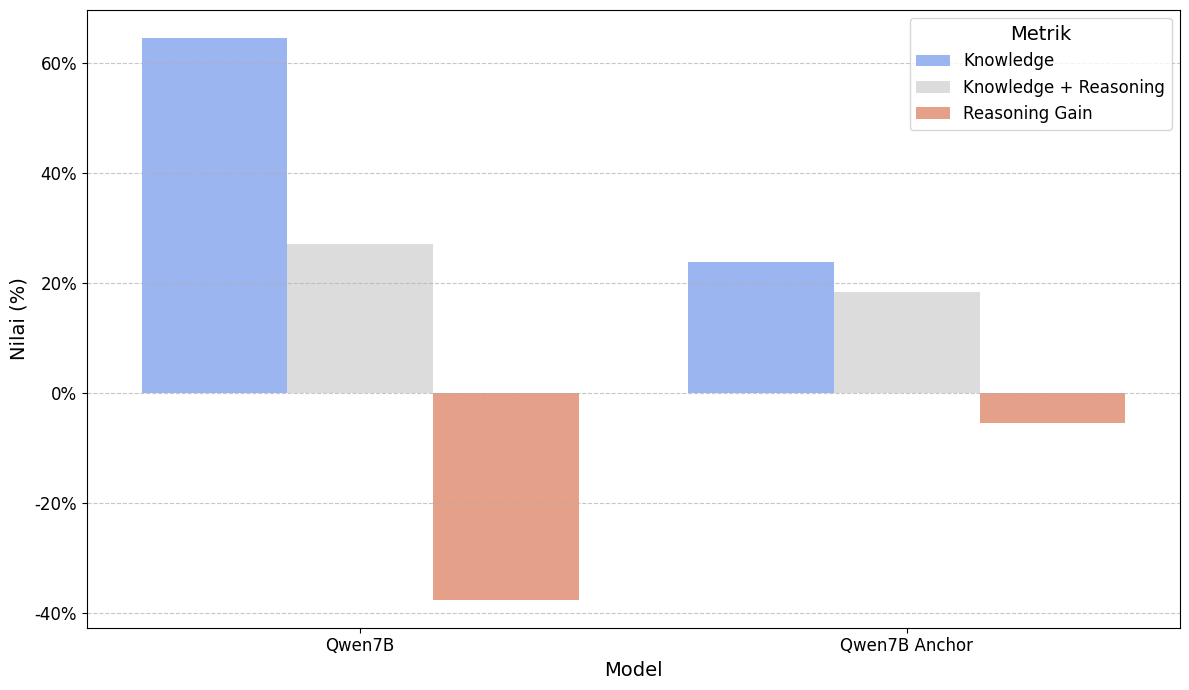

In [110]:
chart2_df = results_df[results_df['Dataset'].isin(['Qwen7B', 'Qwen7B Anchor'])].copy()

# Convert percentage strings to float
chart2_df['Fast Accuracy'] = chart2_df['Fast Accuracy'].str.rstrip('%').astype(float) / 100
chart2_df['Slow Accuracy'] = chart2_df['Slow Accuracy'].str.rstrip('%').astype(float) / 100
chart2_df['Capability Reasoning Adjustment (CRA)'] = chart2_df['Capability Reasoning Adjustment (CRA)'].str.rstrip('%').astype(float) / 100

# Rename column for clarity
chart2_df = chart2_df.rename(columns={'Fast Accuracy': 'Knowledge'})
chart2_df = chart2_df.rename(columns={'Slow Accuracy': 'Knowledge + Reasoning'})
chart2_df = chart2_df.rename(columns={'Capability Reasoning Adjustment (CRA)': 'Reasoning Gain'})

# Melt the DataFrame for plotting
chart2_melted = chart2_df.melt(
    id_vars='Dataset',
    value_vars=['Knowledge', 'Knowledge + Reasoning', 'Reasoning Gain'],
    var_name='Metric',
    value_name='Value'
)

# Define the desired order for metrics on the hue (for bar ordering within each model)
metric_order = ['Knowledge', 'Knowledge + Reasoning', 'Reasoning Gain']
chart2_melted['Metric'] = pd.Categorical(chart2_melted['Metric'], categories=metric_order, ordered=True)

plt.figure(figsize=(12, 7))
sns.barplot(x='Dataset', y='Value', hue='Metric', data=chart2_melted, palette='coolwarm') # Changed x and hue roles
plt.xlabel('Model', fontsize=14)
plt.ylabel('Nilai (%)', fontsize=14)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y))) # Format as percentage
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0, ha='center', fontsize=12, fontstyle='normal') # Reduced rotation, ensured non-italic
plt.yticks(fontsize=12)
plt.legend(title='Metrik', fontsize=12, title_fontsize=14) # Updated legend title
plt.tight_layout()
plt.show()

### Chart 3: Capability Metrics Across Models (Line Chart)


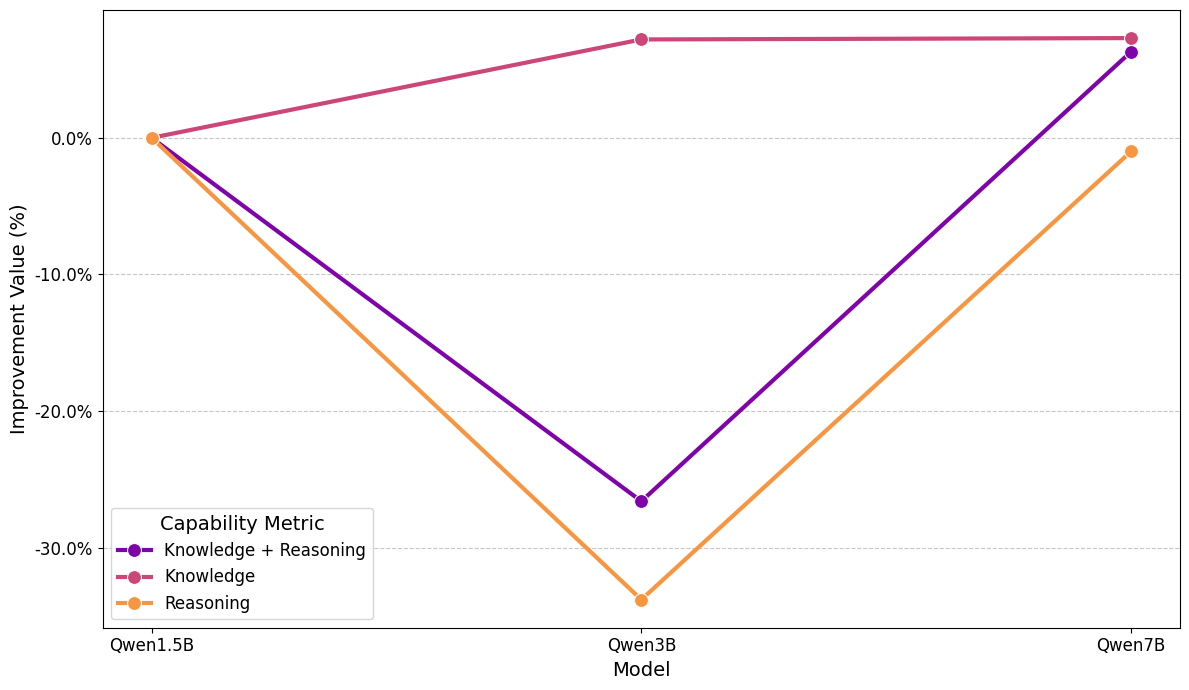

In [113]:
# Prepare data for Chart 3: Capability Metrics
chart3_base_df = results_df[results_df['Dataset'] != 'Qwen7B Anchor'].copy()

# Convert percentage strings to float
chart3_base_df['Slow Accuracy'] = chart3_base_df['Slow Accuracy'].str.rstrip('%').astype(float) / 100
chart3_base_df['Capability Knowledge Retrieval (CKR)'] = chart3_base_df['Capability Knowledge Retrieval (CKR)'].str.rstrip('%').astype(float) / 100
chart3_base_df['Capability Reasoning Adjustment (CRA)'] = chart3_base_df['Capability Reasoning Adjustment (CRA)'].str.rstrip('%').astype(float) / 100

# Set 'Dataset' as index for easier calculation
chart3_base_df = chart3_base_df.set_index('Dataset')

# Initialize a DataFrame to store improvement deltas
improvement_metrics_df = pd.DataFrame(
    index=['Qwen1.5B', 'Qwen3B', 'Qwen7B'],
    columns=['Slow Accuracy Improvement', 'CKR Improvement', 'CRA Improvement']
)

# Qwen1.5B is the baseline (0 improvement relative to itself)
for col in ['Slow Accuracy', 'Capability Knowledge Retrieval (CKR)', 'Capability Reasoning Adjustment (CRA)']:
    base_col_name = col.replace('Capability Knowledge Retrieval (CKR)', 'CKR').replace('Capability Reasoning Adjustment (CRA)', 'CRA')
    improvement_metrics_df.loc['Qwen1.5B', f'{base_col_name} Improvement'] = 0

# Calculate improvement from Qwen1.5B to Qwen3B
for col_raw, col_imp in zip(
    ['Slow Accuracy', 'Capability Knowledge Retrieval (CKR)', 'Capability Reasoning Adjustment (CRA)'],
    ['Slow Accuracy Improvement', 'CKR Improvement', 'CRA Improvement']
):
    improvement_metrics_df.loc['Qwen3B', col_imp] = chart3_base_df.loc['Qwen3B', col_raw] - chart3_base_df.loc['Qwen1.5B', col_raw]

# Calculate improvement from Qwen3B to Qwen7B
for col_raw, col_imp in zip(
    ['Slow Accuracy', 'Capability Knowledge Retrieval (CKR)', 'Capability Reasoning Adjustment (CRA)'],
    ['Slow Accuracy Improvement', 'CKR Improvement', 'CRA Improvement']
):
    improvement_metrics_df.loc['Qwen7B', col_imp] = chart3_base_df.loc['Qwen7B', col_raw] - chart3_base_df.loc['Qwen3B', col_raw]

# Reset index to make 'Dataset' a column again for melting
improvement_metrics_df = improvement_metrics_df.reset_index().rename(columns={'index': 'Model'})

# Rename the columns to match the desired labels for plotting
improvement_metrics_df = improvement_metrics_df.rename(columns={
    'Slow Accuracy Improvement': 'Knowledge + Reasoning',
    'CKR Improvement': 'Knowledge',
    'CRA Improvement': 'Reasoning'
})

# Melt the DataFrame for plotting
chart3_melted = improvement_metrics_df.melt(
    id_vars='Model',
    value_vars=['Knowledge + Reasoning', 'Knowledge', 'Reasoning'],
    var_name='Capability Metric',
    value_name='Improvement Value'
)

plt.figure(figsize=(12, 7))
sns.lineplot(x='Model', y='Improvement Value', hue='Capability Metric', data=chart3_melted, marker='o', palette='plasma', linewidth=3, markersize=10)
plt.xlabel('Model', fontsize=14) # Increased fontsize
plt.ylabel('Improvement Value (%)', fontsize=14) # Increased fontsize
# Set y-axis formatter to percentage, handling potentially negative values
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y))) # Format as percentage with one decimal
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(fontsize=12) # Increased fontsize
plt.yticks(fontsize=12) # Increased fontsize
plt.legend(title='Capability Metric', fontsize=12, title_fontsize=14) # Increased fontsize
plt.tight_layout()
plt.show()

### Slow Label Distribution (Overthinking) in Table Format

As requested, here's the 'Slow Label Distribution (Overthinking)' presented in a table format for better readability, especially when one category dominates the distribution.

In [127]:
percentage_table_data = []

# Filter out 'Qwen7B Anchor' from results_df before processing
filtered_results_df = results_df[results_df['Dataset'] != 'Qwen7B Anchor'].copy()

for index, row in filtered_results_df.iterrows():
    dataset_name = row['Dataset']
    overthinking_count = row['Overthinking Count']
    overthinking_dist = row['Slow Label Distribution (Overthinking)']

    if overthinking_count > 0 and overthinking_dist and isinstance(overthinking_dist, dict):
        percentage_dist = {label: (count / overthinking_count) * 100 for label, count in overthinking_dist.items()}
        percentage_dist['Overthinking Count'] = float(overthinking_count) # Keep as float temporarily for consistency
        percentage_series = pd.Series(percentage_dist, name=dataset_name)
        percentage_table_data.append(percentage_series)
    else:
        # Handle cases with no data or zero overthinking count
        percentage_table_data.append(pd.Series({'Overthinking Count': float(overthinking_count), 'N/A': float('nan')}, name=dataset_name))

# Combine all series into a single DataFrame with numeric types
if percentage_table_data:
    temp_percentage_overthinking_table_df = pd.concat(percentage_table_data, axis=1).fillna(0)

    # Define the desired order for the labels
    desired_label_order = ['Either', 'Supports', 'Opposes']

    # Reorder rows (which will become columns after transpose) for consistent display
    existing_rows = temp_percentage_overthinking_table_df.index.tolist()
    new_rows_order = ['Overthinking Count'] + \
                     [col for col in desired_label_order if col in existing_rows] + \
                     [col for col in existing_rows if col not in desired_label_order and col != 'Overthinking Count']

    temp_percentage_overthinking_table_df = temp_percentage_overthinking_table_df.loc[new_rows_order].copy()

    # Now, create a new DataFrame for formatted strings to avoid FutureWarning
    formatted_percentage_overthinking_table_df = pd.DataFrame(index=temp_percentage_overthinking_table_df.index,
                                                              columns=temp_percentage_overthinking_table_df.columns,
                                                              dtype=object)

    # Format 'Overthinking Count' row to integer strings
    formatted_percentage_overthinking_table_df.loc['Overthinking Count'] = temp_percentage_overthinking_table_df.loc['Overthinking Count'].astype(int).astype(str)

    # Format other rows as percentages
    for row_label in temp_percentage_overthinking_table_df.index.drop('Overthinking Count'):
        formatted_percentage_overthinking_table_df.loc[row_label] = temp_percentage_overthinking_table_df.loc[row_label].apply(lambda x: f'{x:.2f}%' if pd.notna(x) else 'N/A')

    display(formatted_percentage_overthinking_table_df.T) # Transpose to have Datasets as rows
else:
    print("No overthinking distribution data available to display in table format.")

,Overthinking Count,Either,Supports,Opposes
Qwen1.5B,111,22.52%,72.07%,5.41%
Qwen3B,507,97.44%,1.38%,1.18%
Qwen7B,480,97.29%,1.25%,1.46%
